# HDT 5: Árboles, Selección de Modelos y Bosques

**Ciencia de Datos, Sección A** · Asignada: martes 29 de septiembre · **Entrega: martes 6 de octubre, 23:59**

**Nombre:** Juan Pablo Madriz

Completar las celdas marcadas con `# ¿Qué va aquí?`. Cada ejercicio incluye una verificación comentada: descomentar para comprobar el resultado. Antes de entregar: **Kernel → Restart & Run All** (un notebook que no corre de arriba a abajo pierde 0.5 pts).

AI: resolver sin AI. Si se usó para entender un concepto, anotarlo en la bitácora del final (no penaliza).

## Setup

Dependencias: `pip install numpy pandas matplotlib scikit-learn`. Todo es determinista (semillas fijas y split fijo): las verificaciones son exactas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL, ROJO, GRIS, LINEA = "#3A6EA5", "#B04A2E", "#75808E", "#E0E4EA"

def eje_limpio(ax):
    ax.grid(color=LINEA, lw=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

## Los datos

Un gimnasio quiere saber qué socios van a darse de baja. Historial de 1,000 socios: `visitas` (al mes), `meses` (antigüedad como socio), `cuota` (quetzales al mes) y `se_va` (1 = no renovó). El mismo tipo de problema que la mora del banco de las sesiones 15 a 17, con otro negocio.

La celda genera los datos completa; no hay nada que llenar aquí.

In [2]:
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(5)
n = 1000
visitas = np.minimum(rng.poisson(8, n), 30)
meses = rng.integers(1, 49, n)
cuota = rng.normal(400, 90, n).clip(200, 700).round(0)

riesgo = (-2.4 + 1.6 * (visitas <= 5) + 1.1 * (meses <= 12)
          + 0.9 * (cuota >= 480) + 1.1 * ((visitas <= 5) & (meses <= 12)))
se_va = (rng.random(n) < 1 / (1 + np.exp(-riesgo))).astype(int)

df = pd.DataFrame({"visitas": visitas, "meses": meses, "cuota": cuota, "se_va": se_va})
columnas = ["visitas", "meses", "cuota"]
X_train, X_test, y_train, y_test = train_test_split(
    df[columnas], df["se_va"], test_size=0.3, random_state=42)

print("socios:", len(df), "| fracción que se va:", df["se_va"].mean().round(3))
print("entrenamiento:", len(X_train), "| examen:", len(X_test))
df.head()

socios: 1000 | fracción que se va: 0.187
entrenamiento: 700 | examen: 300


,visitas,meses,cuota,se_va
0,7,25,502.0,0
1,10,6,373.0,0
2,6,44,543.0,0
3,5,39,489.0,1
4,8,3,490.0,1


## Parte A · Un árbol (0.5 pt)

El modelo de preguntas de la sesión 15: elegir el corte que deja los grupos menos mezclados, y la profundidad como perilla.

### Ejercicio 1 (0.15): la mezcla a mano

Con la función `mezcla` de clase, sobre el **entrenamiento** (700 socios, 132 se van): (a) la mezcla sin cortar nada; (b) la mezcla promedio ponderada del corte `visitas <= 5`; (c) la del corte `meses <= 12`. ¿Cuál de los dos cortes gana, y coincide con la primera pregunta que elige un árbol de profundidad 1?

In [ ]:
def mezcla(se_van, se_quedan):
    p = se_van / (se_van + se_quedan)
    return 1 - p**2 - (1 - p)**2

def mezcla_del_corte(columna, corte):
    lado = X_train[columna] <= corte
    total = len(X_train)
    promedio = 0.0
    for dentro in (lado, ~lado):          # los dos grupos que deja el corte
        y_lado = y_train[dentro]
        se_van = int(y_lado.sum())
        se_quedan = len(y_lado) - se_van
        promedio += len(y_lado) / total * mezcla(se_van, se_quedan)
    return promedio

se_van_total = int(y_train.sum())
m_total = mezcla(se_van_total, len(y_train) - se_van_total)   # mezcla de los 700 sin cortar
m_visitas = mezcla_del_corte("visitas", 5)
m_meses = mezcla_del_corte("meses", 12)

print(f"sin cortar          mezcla = {m_total:.3f}")
print(f"corte visitas <= 5  mezcla = {m_visitas:.3f}  (baja {m_total - m_visitas:.3f})")
print(f"corte meses   <= 12 mezcla = {m_meses:.3f}  (baja {m_total - m_meses:.3f})")

# la primera pregunta que elige un árbol de profundidad 1:
from sklearn.tree import DecisionTreeClassifier, export_text
arbol_1 = DecisionTreeClassifier(max_depth=1, random_state=0).fit(X_train, y_train)
print("\nárbol de profundidad 1:")
print(export_text(arbol_1, feature_names=columnas))


# Verificación (descomentar):
assert round(m_total, 3) == 0.306
assert round(m_visitas, 3) == 0.252
assert round(m_meses, 3) == 0.290
print("verificación OK")

sin cortar          mezcla = 0.306
corte visitas <= 5  mezcla = 0.252  (baja 0.054)
corte meses   <= 12 mezcla = 0.290  (baja 0.016)

árbol de profundidad 1:
|--- visitas <= 5.50
|   |--- class: 1
|--- visitas >  5.50
|   |--- class: 0

verificación OK


### Ejercicio 2 (0.20): la profundidad es la perilla

Para cada profundidad en [1, 2, 3, 4, 6, 8, 12]: entrenar un árbol (`random_state=0`) y guardar aciertos en entrenamiento y en examen. Graficar las dos curvas (AZUL entrenamiento, ROJO examen) con `eje_limpio`. Responder en un comentario: ¿qué profundidad elegirían y por qué?

profundidad  entrenamiento  examen
         1          0.819   0.830
         2          0.850   0.850
         3          0.860   0.860
         4          0.870   0.840
         6          0.896   0.830
         8          0.934   0.807
        12          0.991   0.767


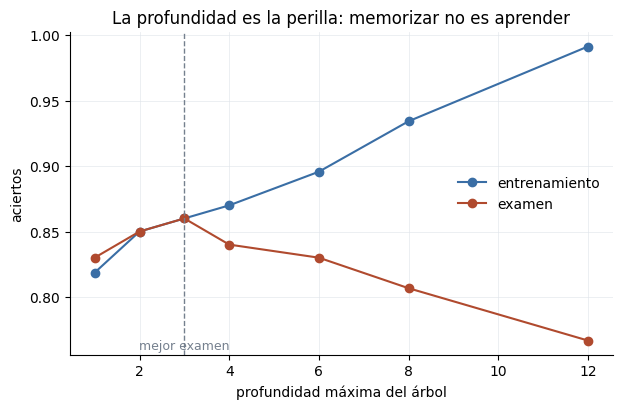

verificación OK


In [ ]:
from sklearn.tree import DecisionTreeClassifier

profundidades = [1, 2, 3, 4, 6, 8, 12]
acc_train = []
acc_test = []

for d in profundidades:
    arbol = DecisionTreeClassifier(max_depth=d, random_state=0).fit(X_train, y_train)
    acc_train.append(arbol.score(X_train, y_train))
    acc_test.append(arbol.score(X_test, y_test))

print("profundidad  entrenamiento  examen")
for d, a_tr, a_te in zip(profundidades, acc_train, acc_test):
    print(f"{d:>10d}  {a_tr:13.3f}  {a_te:6.3f}")

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(profundidades, acc_train, "o-", color=AZUL, label="entrenamiento")
ax.plot(profundidades, acc_test, "o-", color=ROJO, label="examen")
ax.axvline(3, color=GRIS, lw=1, ls="--")
ax.annotate("mejor examen", (3, 0.76), color=GRIS, fontsize=9, ha="center")
ax.set_xlabel("profundidad máxima del árbol")
ax.set_ylabel("aciertos")
ax.set_title("La profundidad es la perilla: memorizar no es aprender")
ax.legend(frameon=False)
eje_limpio(ax)
plt.show()


# Verificación (descomentar):
assert round(acc_test[2], 2) == 0.86      # profundidad 3
assert round(acc_train[6], 3) == 0.991 and round(acc_test[6], 3) == 0.767
print("verificación OK")

### Ejercicio 3 (0.15): un árbol solo es inestable

Entrenar 25 árboles **sin límite de profundidad**, cada uno con 350 socios del entrenamiento elegidos al azar (`np.random.default_rng(s).choice(len(X_train), 350, replace=False)` con `s` de 0 a 24), y guardar sus aciertos en el examen. Reportar el mínimo y el máximo. De paso: imprimir la primera pregunta de los árboles con `s` de 0 a 3 (profundidad 2) y observar que esa sí es estable.

In [ ]:
from sklearn.tree import export_text

aciertos = []
for s in range(25):
    idx = np.random.default_rng(s).choice(len(X_train), 350, replace=False)
    arbol = DecisionTreeClassifier(random_state=0).fit(X_train.iloc[idx], y_train.iloc[idx])
    aciertos.append(arbol.score(X_test, y_test))

print(f"25 árboles sin límite, 350 socios cada uno:")
print(f"  mínimo   = {min(aciertos):.3f}")
print(f"  máximo   = {max(aciertos):.3f}")
print(f"  promedio = {np.mean(aciertos):.3f}  (rango de {max(aciertos) - min(aciertos):.3f})")

print("\nprimera pregunta (profundidad 2), semillas 0 a 3:")
for s in range(4):
    idx = np.random.default_rng(s).choice(len(X_train), 350, replace=False)
    corto = DecisionTreeClassifier(max_depth=2, random_state=0).fit(X_train.iloc[idx], y_train.iloc[idx])
    primera = export_text(corto, feature_names=columnas).splitlines()[0].replace("|---", "").strip()
    print(f"  s={s}:  {primera}")

# Verificación (descomentar):
assert round(min(aciertos), 3) == 0.73
assert round(max(aciertos), 3) == 0.8
print("verificación OK")

25 árboles sin límite, 350 socios cada uno:
  mínimo   = 0.730
  máximo   = 0.800
  promedio = 0.773  (rango de 0.070)

primera pregunta (profundidad 2), semillas 0 a 3:
  s=0:  visitas <= 5.50
  s=1:  visitas <= 5.50
  s=2:  visitas <= 5.50
  s=3:  visitas <= 5.50
verificación OK


## Parte B · Elegir sin trampa (0.5 pt)

La sesión 16 en tres pasos: comparar candidatos con validación cruzada, afinar perillas con búsqueda, y tocar el examen una sola vez.

### Ejercicio 4 (0.20): tres candidatos, el mismo procedimiento

Comparar con validación cruzada estratificada de 5 pliegues (`StratifiedKFold(n_splits=5, shuffle=True, random_state=7)`) sobre el **entrenamiento**: logística (con escala, en Pipeline), árbol (`max_depth=4`) y kNN (con escala, `n_neighbors=15`). Imprimir promedio y desviación de cada uno. ¿Quién gana?

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)
candidatos = {
    "logística": make_pipeline(StandardScaler(), LogisticRegression()),
    "árbol": DecisionTreeClassifier(max_depth=4, random_state=0),
    "kNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15)),
}

promedios = {}
for nombre, modelo in candidatos.items():
    puntajes = cross_val_score(modelo, X_train, y_train, cv=cv)
    promedios[nombre] = puntajes.mean()
    print(f"{nombre:10s} {puntajes.mean():.3f} ± {puntajes.std():.3f}   "
          f"pliegues: {np.round(puntajes, 3)}")

ganador = max(promedios, key=promedios.get)
print(f"\ngana: {ganador} con {promedios[ganador]:.3f}")


# Verificación (descomentar):
assert round(promedios["árbol"], 3) == 0.846
assert promedios["árbol"] == max(promedios.values())
print("verificación OK")

logística  0.827 ± 0.019   pliegues: [0.814 0.814 0.821 0.864 0.821]
árbol      0.846 ± 0.012   pliegues: [0.85  0.864 0.829 0.85  0.836]
kNN        0.827 ± 0.013   pliegues: [0.843 0.814 0.814 0.843 0.821]

gana: árbol con 0.846
verificación OK


### Ejercicio 5 (0.15): afinar las perillas del ganador

`GridSearchCV` sobre el árbol con `max_depth` en [2, 3, 4, 6] y `min_samples_leaf` en [5, 20, 50], usando el mismo `cv`. ¿Cuántas combinaciones probó? Imprimir la mejor y su puntaje.

In [7]:
from sklearn.model_selection import GridSearchCV

malla = {"max_depth": [2, 3, 4, 6], "min_samples_leaf": [5, 20, 50]}
busqueda = GridSearchCV(DecisionTreeClassifier(random_state=0), malla, cv=cv)
busqueda.fit(X_train, y_train)

combinaciones = len(busqueda.cv_results_["params"])
print(f"combinaciones probadas = {combinaciones}  (4 profundidades × 3 tamaños de hoja)")
print(f"ajustes totales        = {combinaciones * cv.get_n_splits()} (cada combinación en 5 pliegues)")
print(f"mejor combinación      = {busqueda.best_params_}")
print(f"mejor puntaje (CV)     = {busqueda.best_score_:.3f}")

# Verificación (descomentar):
assert busqueda.best_params_ == {"max_depth": 3, "min_samples_leaf": 20}
assert round(busqueda.best_score_, 3) == 0.856
print("verificación OK")

combinaciones probadas = 12  (4 profundidades × 3 tamaños de hoja)
ajustes totales        = 60 (cada combinación en 5 pliegues)
mejor combinación      = {'max_depth': 3, 'min_samples_leaf': 20}
mejor puntaje (CV)     = 0.856
verificación OK


### Ejercicio 6 (0.15): el examen se usa una vez

Tomar `busqueda.best_estimator_` (ya viene entrenado con los 700) y evaluarlo en el examen. Responder en un comentario: ¿por qué este número puede ser distinto del 0.856 anterior, y por qué no se vale seguir probando modelos después de verlo?

In [ ]:
examen_final = busqueda.best_estimator_.score(X_test, y_test)

print(f"simulacro (CV sobre los 700) = {busqueda.best_score_:.3f}")
print(f"examen (300 socios nunca vistos) = {examen_final:.3f}")

# Verificación (descomentar):
assert round(examen_final, 3) == 0.86
print("verificación OK")

simulacro (CV sobre los 700) = 0.856
examen (300 socios nunca vistos) = 0.860
verificación OK


## Parte C · El bosque (0.8 pt)

La sesión 17: si un árbol baila, que voten muchos. Bootstrap, bagging a mano, OOB e importancias.

### Ejercicio 7 (0.20): bagging a mano

Para B en [1, 5, 25, 100]: entrenar B árboles sin límite, cada uno con una muestra bootstrap (`np.random.default_rng(b).integers(0, len(X_train), len(X_train))` con `b` de 0 a B-1), sumar sus votos sobre el examen y clasificar por mayoría (`votos / B >= 0.5`). Guardar los aciertos en `aciertos_bagging` y graficar contra B.

B =   1 árbol  -> aciertos en examen = 0.767
B =   5 árboles -> aciertos en examen = 0.787
B =  25 árboles -> aciertos en examen = 0.820
B = 100 árboles -> aciertos en examen = 0.823


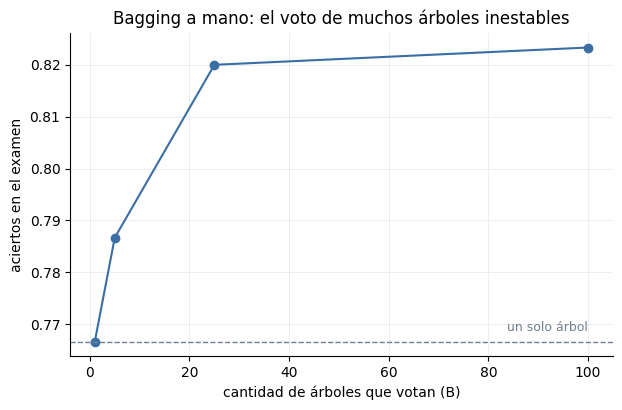

verificación OK


In [ ]:
cantidades = [1, 5, 25, 100]
aciertos_bagging = []

for B in cantidades:
    votos = np.zeros(len(X_test))
    for b in range(B):
        idx = np.random.default_rng(b).integers(0, len(X_train), len(X_train))
        arbol = DecisionTreeClassifier(random_state=0).fit(X_train.iloc[idx], y_train.iloc[idx])
        votos += arbol.predict(X_test)
    prediccion = (votos / B >= 0.5).astype(int)
    aciertos_bagging.append((prediccion == y_test.values).mean())
    plural = "árbol " if B == 1 else "árboles"
    print(f"B = {B:3d} {plural} -> aciertos en examen = {aciertos_bagging[-1]:.3f}")

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(cantidades, aciertos_bagging, "o-", color=AZUL)
ax.axhline(aciertos_bagging[0], color=GRIS, lw=1, ls="--")
ax.annotate("un solo árbol", (100, aciertos_bagging[0] + 0.002),
            color=GRIS, fontsize=9, ha="right")
ax.set_xlabel("cantidad de árboles que votan (B)")
ax.set_ylabel("aciertos en el examen")
ax.set_title("Bagging a mano: el voto de muchos árboles inestables")
eje_limpio(ax)
plt.show()

# Verificación (descomentar):
assert [round(a, 3) for a in aciertos_bagging] == [0.767, 0.787, 0.82, 0.823]
print("verificación OK")

### Ejercicio 8 (0.20): las perillas del bosque, medidas con OOB

Para `min_samples_leaf` en [1, 5, 10, 20, 50]: RandomForest de 300 árboles con `oob_score=True` (`random_state=0, n_jobs=-1`), guardar el OOB de cada uno en el diccionario `oobs`. Elegir el mejor y reportar su examen. Todo sin usar el examen para elegir: para eso está el OOB.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

oobs = {}
for msl in [1, 5, 10, 20, 50]:
    bosque = RandomForestClassifier(n_estimators=300, min_samples_leaf=msl,
                                    oob_score=True, random_state=0, n_jobs=-1)
    bosque.fit(X_train, y_train)
    oobs[msl] = bosque.oob_score_
    print(f"min_samples_leaf = {msl:2d} -> OOB = {bosque.oob_score_:.3f}")

mejor_msl = max(oobs, key=oobs.get)              # la perilla con mayor OOB
bosque_final = RandomForestClassifier(n_estimators=300, min_samples_leaf=mejor_msl,
                                      random_state=0, n_jobs=-1).fit(X_train, y_train)
examen_bosque = bosque_final.score(X_test, y_test)

print(f"\nmejor min_samples_leaf = {mejor_msl} (OOB = {oobs[mejor_msl]:.3f})")
print(f"examen del bosque ganador = {examen_bosque:.3f}")

# Verificación (descomentar):
assert mejor_msl == 5 and round(oobs[5], 3) == 0.857
assert round(examen_bosque, 3) == 0.86
print("verificación OK")

min_samples_leaf =  1 -> OOB = 0.831
min_samples_leaf =  5 -> OOB = 0.857
min_samples_leaf = 10 -> OOB = 0.856
min_samples_leaf = 20 -> OOB = 0.846
min_samples_leaf = 50 -> OOB = 0.811

mejor min_samples_leaf = 5 (OOB = 0.857)
examen del bosque ganador = 0.860
verificación OK


### Ejercicio 9 (0.20): la señal arriba, el ruido abajo

Agregar al entrenamiento una columna `ruido` de puro azar (`np.random.default_rng(9).normal(0, 1, len(X_train))`), entrenar un bosque (300 árboles, `min_samples_leaf=20`, `random_state=0`) y ordenar las importancias de mayor a menor. ¿Dónde quedó el ruido?

visitas    0.562
meses      0.236
cuota      0.111
ruido      0.091


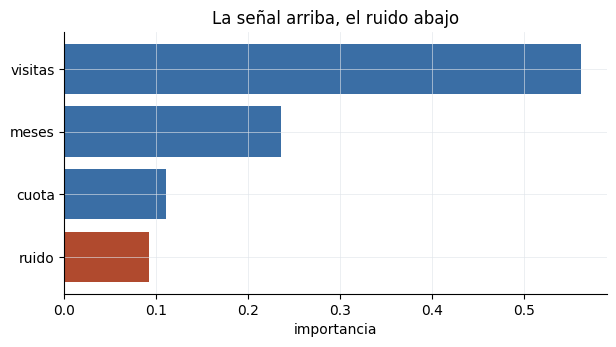

verificación OK


In [ ]:
X_train_ruido = X_train.copy()
X_train_ruido["ruido"] = np.random.default_rng(9).normal(0, 1, len(X_train))

bosque_ruido = RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                                      random_state=0).fit(X_train_ruido, y_train)
importancias = pd.Series(bosque_ruido.feature_importances_,
                         index=X_train_ruido.columns).sort_values(ascending=False)

print(importancias.round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 3.4))
colores = [ROJO if nombre == "ruido" else AZUL for nombre in importancias.index]
ax.barh(importancias.index[::-1], importancias.values[::-1], color=colores[::-1])
ax.set_xlabel("importancia")
ax.set_title("La señal arriba, el ruido abajo")
eje_limpio(ax)
plt.show()

# Verificación (descomentar):
assert importancias.index[0] == "visitas" and importancias.index[-1] == "ruido"
assert round(importancias["ruido"], 3) == 0.091
print("verificación OK")


### Ejercicio 10 (0.20): un árbol contra un bosque, diez veces

Repetir 10 veces (repartos `train_test_split` con `random_state` de 0 a 9): entrenar un árbol sin límite y un bosque (200 árboles, `min_samples_leaf=20`) y guardar los aciertos de examen de cada uno. Reportar mínimo y máximo de cada modelo. ¿Qué se observa?

reparto   árbol   bosque
      0   0.753   0.820
      1   0.780   0.840
      2   0.777   0.860
      3   0.797   0.837
      4   0.800   0.847
      5   0.777   0.850
      6   0.790   0.880
      7   0.710   0.857
      8   0.780   0.853
      9   0.730   0.850

árbol : min 0.710  max 0.800  promedio 0.769  rango 0.090
bosque: min 0.820  max 0.880  promedio 0.849  rango 0.060


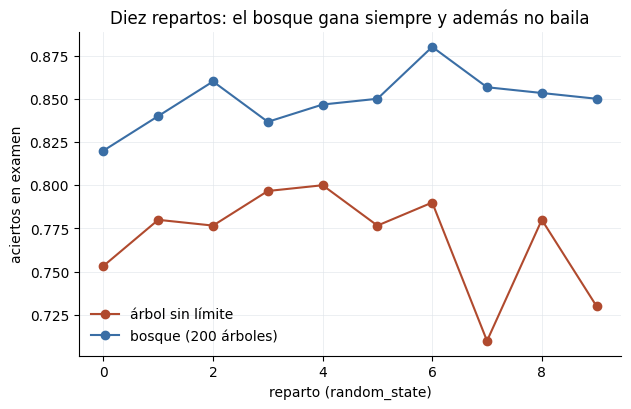

verificación OK


In [ ]:
arbol_res = []
bosque_res = []

for s in range(10):
    Xtr, Xte, ytr, yte = train_test_split(
        df[columnas], df["se_va"], test_size=0.3, random_state=s)
    arbol = DecisionTreeClassifier(random_state=0).fit(Xtr, ytr)
    bosque = RandomForestClassifier(n_estimators=200, min_samples_leaf=20,
                                    random_state=0).fit(Xtr, ytr)
    arbol_res.append(arbol.score(Xte, yte))
    bosque_res.append(bosque.score(Xte, yte))

print("reparto   árbol   bosque")
for s, (a, b) in enumerate(zip(arbol_res, bosque_res)):
    print(f"{s:>7d}   {a:.3f}   {b:.3f}")

print(f"\nárbol : min {min(arbol_res):.3f}  max {max(arbol_res):.3f}  "
      f"promedio {np.mean(arbol_res):.3f}  rango {max(arbol_res) - min(arbol_res):.3f}")
print(f"bosque: min {min(bosque_res):.3f}  max {max(bosque_res):.3f}  "
      f"promedio {np.mean(bosque_res):.3f}  rango {max(bosque_res) - min(bosque_res):.3f}")

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(range(10), arbol_res, "o-", color=ROJO, label="árbol sin límite")
ax.plot(range(10), bosque_res, "o-", color=AZUL, label="bosque (200 árboles)")
ax.set_xlabel("reparto (random_state)")
ax.set_ylabel("aciertos en examen")
ax.set_title("Diez repartos: el bosque gana siempre y además no baila")
ax.legend(frameon=False)
eje_limpio(ax)
plt.show()

# Verificación (descomentar):
assert round(min(arbol_res), 3) == 0.71 and round(max(arbol_res), 3) == 0.8
assert round(min(bosque_res), 3) == 0.82 and round(max(bosque_res), 3) == 0.88
print("verificación OK")


## Parte D · Criterio (0.2 pt)

### Ejercicio 11 (0.20)

Dos preguntas, 2-3 líneas cada una, **citando los números obtenidos**:

**(a)** El 0.856 del ejercicio 5 y el 0.86 del ejercicio 6 se parecen, pero no son intercambiables. Explicar qué es cada número, cuál se reporta a gerencia y por qué el examen se usa una sola vez.

**(b)** El gimnasio va a desplegar un modelo para llamar a socios en riesgo. Con los resultados de los ejercicios 8 a 10, ¿árbol o bosque? Dar el argumento con números, y mencionar qué se pierde a cambio.

_(Responder editando esta celda)_

**Respuesta (a):** El **0.856** es un *simulacro*: el promedio de 5 pliegues de validación cruzada hechos dentro de los 700 socios de entrenamiento, y es el máximo de las **12 combinaciones** que probó el `GridSearchCV`. Como es un máximo sobre 12 intentos, se queda con el azar que le favoreció y tiende a quedar optimista; sirve para **elegir** (`max_depth=3`, `min_samples_leaf=20` le ganó a las otras 11), no para prometer. El **0.860** es el *examen*: una sola medición del modelo ya elegido sobre 300 socios que no participaron en ninguna decisión, y por eso es el único estimado honesto de lo que va a pasar con socios nuevos. **A gerencia se reporta el 0.860** (y con la advertencia de que con 300 socios un acierto vale 0.003, así que el número real anda en una banda de ±4 puntos, no clavado en 86%). El examen se usa una sola vez porque en el momento en que su resultado cambia qué modelo se despliega —"0.860 no me gustó, probemos otra malla"— el examen deja de ser gente no vista y se convierte en una perilla más: después de tres o cuatro vueltas el número ya no mide el futuro, mide qué tan bien se le ajustó a esos 300 socios en particular.

**Respuesta (b):** **Bosque**, y la evidencia es de los tres ejercicios. En **nivel**: el árbol sin límite anda en 0.767 (ej. 2, profundidad 12) mientras el bosque con `min_samples_leaf=5` da 0.860 en examen con un OOB de 0.857 que lo anticipó sin tocar el examen (ej. 8). En **estabilidad**, que para desplegar pesa igual: en los diez repartos del ejercicio 10 el árbol va de 0.710 a 0.800 (promedio 0.769) y el bosque de 0.820 a 0.880 (promedio 0.849) — el peor reparto del bosque le gana al mejor del árbol, así que el bosque gana 10 de 10 y encima con la mitad del vaivén. Dicho de otro modo: desplegar un árbol es apostar a qué 700 socios entraron al entrenamiento (ej. 3: 0.730 a 0.800 solo cambiando la submuestra); el bosque promedia esa lotería. **Lo que se pierde** es la explicación: el árbol de profundidad 3 se imprime en diez líneas y se le enseña al gerente del gimnasio ("visitas ≤ 5 y meses ≤ 12 → llamar"), mientras que 300 árboles votando no se leen — del bosque solo queda el ranking de importancias (ej. 9: visitas 0.562, meses 0.236, cuota 0.111, y hasta una columna de puro ruido se lleva 0.091), que dice *qué* pesa pero no *en qué dirección* ni con qué corte. También cuesta ~300 veces más entrenar y predecir, aunque con 1,000 socios eso es irrelevante. Compromiso razonable: desplegar el bosque para decidir a quién llamar, y mantener el árbol de profundidad 3 (CV 0.856) como el mapa que se le explica al personal, dado que ambos aciertan 0.860 en el examen y el bosque solo saca ventaja clara cuando el reparto cambia.

## Bitácora de AI (opcional, no penaliza)

Si se usó AI para entender algún concepto, anotar aquí qué se preguntó y qué se entendió. Si no se usó, escribir "No se usó".

- **Sí se usó.** Preguntas sobre el promedio ponderado de Gini al evaluar un corte (por qué se pesa por el tamaño de cada lado y no se promedian las dos mezclas a secas), sobre qué mide exactamente el `oob_score_` de un `RandomForestClassifier` (el ~37% de socios que cada árbol deja fuera de su muestra bootstrap, y por qué eso lo vuelve un simulacro honesto sin gastar el examen) y sobre por qué una columna de puro ruido alcanza importancia 0.091 en vez de 0 (una variable continua ofrece muchos cortes posibles y alguno siempre baja un poco la mezcla dentro de una hoja).